# Simple Diffusion Map on Ising Configurations
This notebook mirrors `simple_diffusion.py` and runs a diffusion map directly on flattened Ising spin configurations.


In [2]:
import csv
import pathlib
import numpy as np

from diffusion_map import diffusion_map

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

RNG = np.random.default_rng(7)
repo_root = pathlib.Path('..').resolve()
config_path = repo_root / 'XYModel' / 'ising_model_configurations.npy'
metadata_path = repo_root / 'XYModel' / 'ising_model_metadata.csv'
config_path, metadata_path


(PosixPath('/workspace/Classifying-BLK-Transitions/XYModel/ising_model_configurations.npy'),
 PosixPath('/workspace/Classifying-BLK-Transitions/XYModel/ising_model_metadata.csv'))

In [3]:
# Hyperparameters
epsilon = None  # set a float to override automatic bandwidth selection
epsilon_samples = 2000
max_samples = None  # e.g., 500 if you want to subsample
n_components = 10
n_dimensions = 3
diffusion_time = 1
use_sparse = False


In [4]:
def load_metadata(path):
    if not path.exists():
        return None
    records = {'temperature': [], 'magnetization': []}
    with path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            records['temperature'].append(float(row['temperature']))
            records['magnetization'].append(float(row['magnetization']))
    return {k: np.asarray(v, dtype=np.float64) for k, v in records.items()}

def pairwise_sq_dists(X):
    norms = np.sum(X ** 2, axis=1, keepdims=True)
    dists = norms + norms.T - 2 * X @ X.T
    np.maximum(dists, 0.0, out=dists)
    return dists

def estimate_epsilon(X, sample_size=None):
    if sample_size is not None and X.shape[0] > sample_size:
        idx = RNG.choice(X.shape[0], size=sample_size, replace=False)
        subset = X[idx]
    else:
        subset = X
    if subset.shape[0] < 2:
        raise ValueError('Need at least two samples for epsilon estimation.')
    dists = pairwise_sq_dists(subset)
    triu = dists[np.triu_indices_from(dists, k=1)]
    return float(np.median(triu))

def choose_indices(n_total, limit):
    if limit is None or limit >= n_total:
        return np.arange(n_total)
    return np.sort(RNG.choice(n_total, size=limit, replace=False))


In [5]:
configs = np.load(config_path)
n_total = configs.shape[0]
flat_configs = configs.reshape(n_total, -1).astype(np.float64)
metadata = load_metadata(metadata_path)
selected_idx = choose_indices(n_total, max_samples)
X_subset = flat_configs[selected_idx]
if epsilon is None:
    epsilon_val = estimate_epsilon(X_subset, epsilon_samples)
else:
    epsilon_val = float(epsilon)
n_total, X_subset.shape, epsilon_val


(200, (200, 4096), 7796.0)

In [ ]:
results = diffusion_map(
    X_subset,
    epsilon=epsilon_val,
    n_components=n_components,
    n_dimensions=n_dimensions,
    t=diffusion_time,
    N=X_subset.shape[1],
    use_sparse=use_sparse,
    verbose=True,
)
embedding = results['embedding']
eigenvalues = results['eigenvalues']
embedding.shape, eigenvalues[:5]


Computing diffusion map...
Diffusion map complete: embedding shape = (200, 3)


((200, 3), array([1.        , 0.24131133, 0.07578018, 0.05634924, 0.0506703 ]))

In [14]:
if metadata is not None:
    temperatures = metadata['temperature'][selected_idx]
    magnetization = metadata['magnetization'][selected_idx]
else:
    temperatures = magnetization = None
    print('Metadata unavailable or mismatched; skipping labeled plots.')

temperatures[:5] if temperatures is not None else 'no metadata'


array([0.1       , 0.11708543, 0.13417085, 0.15125628, 0.16834171])

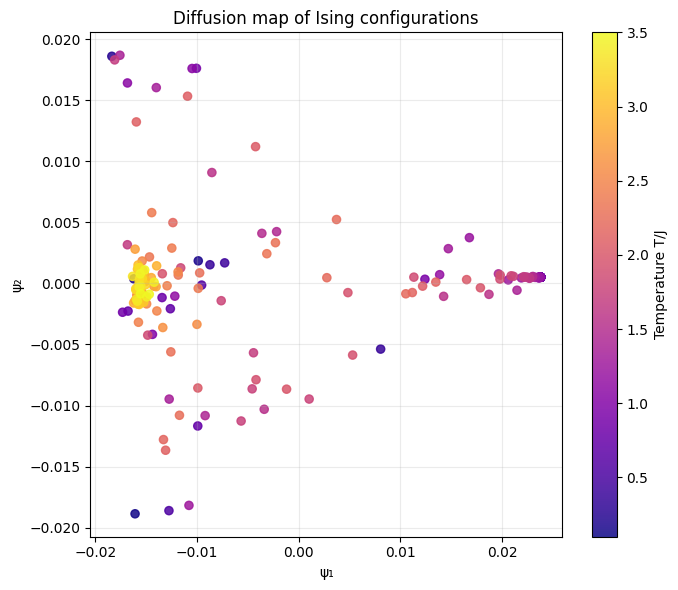

In [15]:
if plt is None:
    print('Matplotlib not installed; skipping scatter plot.')
elif embedding.shape[1] < 2:
    raise ValueError('Need at least two diffusion coordinates for visualization.')
else:
    plt.figure(figsize=(7, 6))
    colors = temperatures if temperatures is not None else selected_idx
    cmap = 'plasma' if temperatures is not None else 'viridis'
    sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, cmap=cmap, s=35, alpha=0.85)
    plt.xlabel('ψ₁')
    plt.ylabel('ψ₂')
    plt.title('Diffusion map of Ising configurations')
    plt.grid(True, alpha=0.25)
    cbar = plt.colorbar(sc)
    cbar.set_label('Temperature T/J' if temperatures is not None else 'Sample index')
    plt.tight_layout()
    plt.show()
